best k value: 9
best accuracy: 0.965


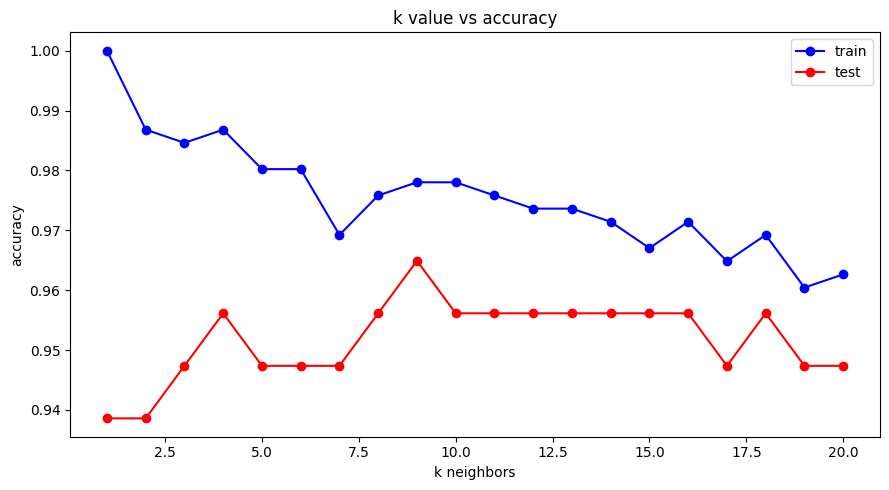

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

cancer = load_breast_cancer()
x = cancer.data
y = cancer.target

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

k_values = range(1, 21)
train_scores = []
test_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train, y_train)
    train_scores.append(model.score(x_train, y_train))
    test_scores.append(model.score(x_test, y_test))

best_k = test_scores.index(max(test_scores)) + 1
print("best k value:", best_k)
print("best accuracy:", round(max(test_scores), 3))

plt.figure(figsize=(9, 5))
plt.plot(k_values, train_scores, marker="o", label="train", color="blue")
plt.plot(k_values, test_scores, marker="o", label="test", color="red")
plt.title("k value vs accuracy")
plt.xlabel("k neighbors")
plt.ylabel("accuracy")
plt.legend()
plt.tight_layout()
plt.show()